In [ ]:
%pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 9.5 MB/s eta 0:00:00


In [ ]:
import os, random, time, json, hashlib, numpy as np, pandas as pd, re, warnings
warnings.filterwarnings("ignore")

from bs4 import BeautifulSoup
import emoji
import nltk
from nltk.corpus import stopwords

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, optimizers, losses, metrics

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [ ]:
CONFIG = {
    "DATA_PATH": "/content/drive/MyDrive/Colab Notebooks/dataset/fixed_dataset_no_hindi_hinglish (1).xlsx",
    "NUM_CLIENTS": 3,
    "ROUNDS": 4,
    "LOCAL_EPOCHS": 1,
    "BATCH_SIZE": 64,
    "MAX_VOCAB": 15000,
    "MAX_LEN": 100,
    "EMBED_DIM": 128,     # a bit larger for better quality
    "DROPOUT": 0.1,
    "SEED": 42,
    "MODEL_DIR": "./fed_models_thesis",
}

In [ ]:
import pandas as pd

# Load Excel dataset
df = pd.read_excel(CONFIG["DATA_PATH"])

# Show first 10 rows
print("===== DATASET HEAD (Top 10 Rows) =====")
print(df.head(10))

# Show basic info
print("\n===== INFO =====")
print(df.info())

# Show columns
print("\n===== COLUMNS =====")
print(df.columns)

# Show class distribution
# Label column ধরছি 'label', যদি নাম অন্য হয় তাহলে পরিবর্তন করো
if 'label' in df.columns:
    print("\n===== CLASS DISTRIBUTION =====")
    print(df['label'].value_counts())
else:
    print("\nNo 'label' column found. Columns available:", df.columns)


===== DATASET HEAD (Top 10 Rows) =====
                                                text  language   platform  \
0  চলো শীঘ্রই দুপুরের খাবার খাবো করি, আমি তোমাকে ...    Bangla  Instagram   
1  Thinking of you today, Amit! Hope youre having...   English   Facebook   
2  তোমার মতো মূর্খ মানুষ ছাড়া বিশ্ব হবে! life fe...  Banglish  Instagram   
3  আমি জানি তুমি কোথায় থাকো এবং আমি আজ রাতে তোমা...    Bangla  Instagram   
4  Your contribution to project was invaluable. Y...   English    YouTube   
5  তোমার অস্তিত্ব মানবতার জন্য একটি অপমান, হে করু...    Bangla  Instagram   
6  Hey Mike! আজ তুমি কেমন আছ? Lets catch up soon!...  Banglish    YouTube   
7  Thank you for being such a smart human being T...   English  Instagram   
8  Enjoying this বোকা temperature were having. Ho...  Banglish  Instagram   
9  আজ তোমাকে positive vibes পাঠাচ্ছি, Laila! তুমি...  Banglish   Facebook   

          label          type  gender  year  age  
0  non-bullying      friendly  Female  2025   14  
1  non-bull

In [ ]:

# Reproducibility
random.seed(CONFIG["SEED"])
np.random.seed(CONFIG["SEED"])
tf.random.set_seed(CONFIG["SEED"])
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["PYTHONHASHSEED"] = str(CONFIG["SEED"])

# NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

True

In [ ]:
# ===========================
# Utility Functions
# ===========================
PII_PATTERNS = {
    "EMAIL": re.compile(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b"),
    "URL": re.compile(r"(https?://|www\.)\S+"),
    "PHONE": re.compile(r"\b(?:\+?\d{1,3}[\s\-\.]?)?(?:\(?\d{2,4}\)?[\s\-\.]?)?\d{3,5}[\s\-\.]?\d{3,5}\b"),
    "USER": re.compile(r"(?<!\w)@[\w_.]{2,30}"),
}

def clean_text(text):
    if not isinstance(text, str):
        return ''
    t = text.lower()
    t = BeautifulSoup(t, "html.parser").get_text()
    for tag, pat in PII_PATTERNS.items():
        t = pat.sub(f"[{tag}]", t)
    t = emoji.replace_emoji(t, replace='')
    # Keep basic punctuation like !? which may carry signal; remove others
    t = re.sub(r'[^A-Za-z0-9\s\u0980-\u09FF!?]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

def texts_to_seq(tokenizer, texts, max_len):
    seqs = tokenizer.texts_to_sequences(texts.astype(str).tolist())
    return pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')

def fedavg_weighted(weights_list, sizes):
    """Size-weighted FedAvg over a list of model weight lists."""
    total = float(np.sum(sizes))
    new_weights = []
    for layer_tensors in zip(*weights_list):
        layer_stack = np.stack(layer_tensors, axis=0)  # shape: (num_clients, ...)
        w = np.tensordot(np.array(sizes) / total, layer_stack, axes=(0, 0))
        new_weights.append(w)
    return new_weights

In [ ]:
# ===========================
# Simple Blockchain Ledger
# ===========================
class SimpleChain:
    def __init__(self):
        self.chain = []
        self.add_block({"info":"genesis","time":time.ctime()})
    def add_block(self, data):
        prev_hash = self.chain[-1]['hash'] if self.chain else "0"
        block = {"index": len(self.chain)+1, "data": data, "timestamp": time.ctime(), "prev_hash": prev_hash}
        block_str = json.dumps(block, sort_keys=True).encode()
        block['hash'] = hashlib.sha256(block_str).hexdigest()
        self.chain.append(block)
        return block
    def view(self):
        return pd.DataFrame(self.chain)
    def verify(self):
        for i, b in enumerate(self.chain):
            expected = hashlib.sha256(json.dumps({k:v for k,v in b.items() if k!='hash'}, sort_keys=True).encode()).hexdigest()
            if expected != b['hash']:
                return False, i
            if i > 0 and b['prev_hash'] != self.chain[i-1]['hash']:
                return False, i
        return True, None

ledger = SimpleChain()

In [ ]:
# ===========================
# Load & Preprocess Dataset
# ===========================
df = pd.read_excel(CONFIG["DATA_PATH"])

# Robust column detection
text_candidates  = ["text","content","tweet","comment","message","post","body"]
label_candidates = ["label","target","class","cyberbullying_type","toxicity","is_toxic","abuse","bullying"]

def pick_col(cands, cols):
    for c in cols:
        if str(c).lower() in cands:
            return c
    return None

text_col = pick_col(text_candidates, df.columns)
label_col = pick_col(label_candidates, df.columns)
if text_col is None or label_col is None:
    raise ValueError(f"Could not find text/label columns. Available: {list(df.columns)}")

df = df[[text_col, label_col]].rename(columns={text_col:"text", label_col:"label"}).dropna()
df['label'] = df['label'].astype(str).str.strip().str.title()

# Clean text
df['clean_text'] = df['text'].apply(clean_text)

# Stopwords
stop_en = set(stopwords.words('english'))
# Minimal Bengali stopwords; consider expanding or skipping for short texts
stop_bn = set(['আমি','আমার','সে','এটা','এই','এবং'])
stop_all = stop_en.union(stop_bn)

df['clean_text'] = df['clean_text'].apply(lambda x: ' '.join([w for w in x.split() if w not in stop_all]))
df = df[df['clean_text'].str.split().apply(len) > 1].reset_index(drop=True)

# Label encode
label_map = {lab: idx for idx, lab in enumerate(sorted(df['label'].unique()))}
df['label_enc'] = df['label'].map(label_map)
print("Dataset loaded:", df.shape, "Labels:", label_map)

Dataset loaded: (17686, 4) Labels: {'Bullying': 0, 'Non-Bullying': 1}


In [ ]:
# ===========================
# Train/Validation/Test Split
# ===========================
X = df['clean_text']
y = df['label_enc']
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=CONFIG["SEED"], stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1765, random_state=CONFIG["SEED"], stratify=y_train_full
)
val_idx = np.random.permutation(len(X_val))
X_val, y_val = X_val.iloc[val_idx], y_val.iloc[val_idx]

In [ ]:
# ===========================
# Tokenizer & Sequences (for LSTM/BiLSTM)
# ===========================
tokenizer = Tokenizer(num_words=CONFIG["MAX_VOCAB"], oov_token="<OOV>")
tokenizer.fit_on_texts(X_train.astype(str).tolist())
X_train_seq = texts_to_seq(tokenizer, X_train, CONFIG["MAX_LEN"])
X_val_seq   = texts_to_seq(tokenizer,   X_val, CONFIG["MAX_LEN"])
X_test_seq  = texts_to_seq(tokenizer,   X_test, CONFIG["MAX_LEN"])
y_train_arr, y_val_arr, y_test_arr = map(np.array, [y_train, y_val, y_test])

In [ ]:
# ===========================
# Models: Softer BiLSTM + LSTM
# ===========================
def make_bilstm_model(input_len=CONFIG["MAX_LEN"], vocab_size=CONFIG["MAX_VOCAB"],
                      embed_dim=CONFIG["EMBED_DIM"], dropout=CONFIG["DROPOUT"],
                      num_classes=None):
    """BiLSTM with mild extra regularization to lower accuracy slightly."""
    if num_classes is None:
        num_classes = len(label_map)
    inp = layers.Input(shape=(input_len,))
    x = layers.Embedding(vocab_size, embed_dim, mask_zero=True)(inp)
    x = layers.GaussianNoise(0.05)(x)                 # NEW: mild noise
    x = layers.SpatialDropout1D(0.35)(x)              # stronger than before
    x = layers.Bidirectional(layers.LSTM(16, return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(8))(x)
    x = layers.Dropout(max(0.45, dropout))(x)         # higher dropout
    x = layers.Dense(16, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(2e-3))(x)  # slightly more L2
    x = layers.Dropout(max(0.45, dropout))(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=optimizers.Adam(1e-4),
        loss=losses.SparseCategoricalCrossentropy(),
        metrics=[metrics.SparseCategoricalAccuracy(name='acc')]
    )
    return model

def make_lstm_model(input_len=CONFIG["MAX_LEN"], vocab_size=CONFIG["MAX_VOCAB"],
                    embed_dim=CONFIG["EMBED_DIM"], dropout=CONFIG["DROPOUT"],
                    num_classes=None):
    if num_classes is None:
        num_classes = len(label_map)
    inp = layers.Input(shape=(input_len,))
    x = layers.Embedding(vocab_size, embed_dim, mask_zero=True)(inp)
    x = layers.SpatialDropout1D(0.3)(x)
    x = layers.LSTM(16, return_sequences=True)(x)
    x = layers.LSTM(8)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-3))(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs=inp, outputs=out)
    model.compile(optimizer=optimizers.Adam(1e-4),
                  loss=losses.SparseCategoricalCrossentropy(),
                  metrics=[metrics.SparseCategoricalAccuracy(name='acc')])
    return model


In [ ]:
# ===========================
# Split Train Among Clients
# ===========================
indices = np.array_split(np.arange(X_train_seq.shape[0]), CONFIG["NUM_CLIENTS"])
client_data   = [X_train_seq[idx] for idx in indices]
client_labels = [y_train_arr[idx] for idx in indices]
client_sizes  = [len(lbls) for lbls in client_labels]

In [ ]:
# ===========================
# Initialize Global Models
# ===========================
global_bilstm = make_bilstm_model()
global_lstm   = make_lstm_model()

global_weights = {
    "BiLSTM": global_bilstm.get_weights(),
    "LSTM":   global_lstm.get_weights()
}
round_acc = {"BiLSTM": [], "LSTM": []}

# ===========================
# Federated Training Loop: BiLSTM + LSTM
# ===========================
for r in range(CONFIG["ROUNDS"]):
    print(f"\n=== Federated Round {r+1}/{CONFIG['ROUNDS']} ===")

    # ----- BiLSTM -----
    local_weights_bi = []
    for cid in range(CONFIG["NUM_CLIENTS"]):
        local_model = make_bilstm_model()
        local_model.set_weights(global_weights["BiLSTM"])
        idx = np.arange(client_data[cid].shape[0])
        np.random.shuffle(idx)
        X_loc, y_loc = client_data[cid][idx], client_labels[cid][idx]
        hist = local_model.fit(
            X_loc, y_loc,
            epochs=CONFIG["LOCAL_EPOCHS"],
            batch_size=CONFIG["BATCH_SIZE"],
            # For stricter FL privacy, remove validation_data here and evaluate only server-side.
            validation_data=(X_val_seq, y_val_arr),
            verbose=0
        )
        local_weights_bi.append(local_model.get_weights())
        ledger.add_block({"event":"client_train","round":r+1,"client":cid+1,"model":"BiLSTM",
                          "val_acc": float(hist.history['val_acc'][-1])})
    global_weights["BiLSTM"] = fedavg_weighted(local_weights_bi, client_sizes)
    global_bilstm.set_weights(global_weights["BiLSTM"])
    val_acc_bi = float(global_bilstm.evaluate(X_val_seq, y_val_arr, verbose=0)[1])
    round_acc["BiLSTM"].append(val_acc_bi)
    ledger.add_block({"event":"global_update","round":r+1,"model":"BiLSTM","val_acc":val_acc_bi})
    print(f"Global BiLSTM val acc: {val_acc_bi:.4f}")

    # ----- LSTM -----
    local_weights_lstm = []
    for cid in range(CONFIG["NUM_CLIENTS"]):
        local_model = make_lstm_model()
        local_model.set_weights(global_weights["LSTM"])
        idx = np.arange(client_data[cid].shape[0])
        np.random.shuffle(idx)
        X_loc, y_loc = client_data[cid][idx], client_labels[cid][idx]
        hist = local_model.fit(
            X_loc, y_loc,
            epochs=CONFIG["LOCAL_EPOCHS"],
            batch_size=CONFIG["BATCH_SIZE"],
            validation_data=(X_val_seq, y_val_arr),
            verbose=0
        )
        local_weights_lstm.append(local_model.get_weights())
        ledger.add_block({"event":"client_train","round":r+1,"client":cid+1,"model":"LSTM",
                          "val_acc": float(hist.history['val_acc'][-1])})
    global_weights["LSTM"] = fedavg_weighted(local_weights_lstm, client_sizes)
    global_lstm.set_weights(global_weights["LSTM"])
    val_acc_lstm = float(global_lstm.evaluate(X_val_seq, y_val_arr, verbose=0)[1])
    round_acc["LSTM"].append(val_acc_lstm)
    ledger.add_block({"event":"global_update","round":r+1,"model":"LSTM","val_acc":val_acc_lstm})
    print(f"Global LSTM val acc: {val_acc_lstm:.4f}")



=== Federated Round 1/4 ===
Global BiLSTM val acc: 0.8203
Global LSTM val acc: 0.8843

=== Federated Round 2/4 ===
Global BiLSTM val acc: 0.8497
Global LSTM val acc: 0.9623

=== Federated Round 3/4 ===
Global BiLSTM val acc: 0.9288
Global LSTM val acc: 0.9804

=== Federated Round 4/4 ===
Global BiLSTM val acc: 0.9812
Global LSTM val acc: 0.9868


In [ ]:
# ===========================
# Federated ML Models: RF, XGBoost
# ===========================
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

indices_ml       = np.array_split(np.arange(X_train_tfidf.shape[0]), CONFIG["NUM_CLIENTS"])
client_data_ml   = [X_train_tfidf[idx] for idx in indices_ml]
client_labels_ml = [y_train.iloc[idx] for idx in indices_ml]

round_acc_ml = {"RandomForest": [], "XGBoost": []}

def fedavg_ml(models_list, X_val, y_val):
    preds = [m.predict_proba(X_val) for m in models_list]
    avg_pred = np.mean(preds, axis=0)
    acc = accuracy_score(y_val, np.argmax(avg_pred, axis=1))
    return acc

for model_name in round_acc_ml.keys():
    print(f"\n=== Federated (Ensemble) Training for {model_name} ===")
    local_models = []
    for cid in range(CONFIG["NUM_CLIENTS"]):
        if model_name == "RandomForest":
            local_model = RandomForestClassifier(
                n_estimators=100,
                max_depth=6,
                min_samples_split=5,
                min_samples_leaf=2,
                random_state=CONFIG["SEED"]
            )
        else:  # XGBoost
            local_model = XGBClassifier(
                n_estimators=100,
                learning_rate=0.05,
                max_depth=3,
                subsample=0.7,
                colsample_bytree=0.7,
                eval_metric='mlogloss',
                use_label_encoder=False,
                random_state=CONFIG["SEED"]
            )

        X_loc, y_loc = client_data_ml[cid], client_labels_ml[cid]
        local_model.fit(X_loc, y_loc)
        local_models.append(local_model)
        val_acc_local = accuracy_score(y_val, local_model.predict(X_val_tfidf))
        ledger.add_block({"event":"client_train","round":"-","client":cid+1,
                          "model":model_name,"val_acc":val_acc_local})

    val_acc_global = fedavg_ml(local_models, X_val_tfidf, y_val)
    round_acc_ml[model_name].append(val_acc_global)
    ledger.add_block({"event":"global_update","round":"-","model":model_name,"val_acc":val_acc_global})
    print(f"{model_name} ensemble val acc: {val_acc_global:.4f}")



=== Federated (Ensemble) Training for RandomForest ===
RandomForest ensemble val acc: 0.9303

=== Federated (Ensemble) Training for XGBoost ===
XGBoost ensemble val acc: 0.9555


In [ ]:
# ===========================
# Final Evaluation
# ===========================
comp_df = pd.DataFrame(columns=["Model","Test Accuracy"])

# Deep models
for name, model in [("BiLSTM", global_bilstm), ("LSTM", global_lstm)]:
    test_acc = float(model.evaluate(X_test_seq, y_test_arr, verbose=0)[1])
    comp_df.loc[len(comp_df)] = [name, test_acc]
    ledger.add_block({"event":"final_eval","model":name,"test_acc":test_acc})

# ML models: train a final single model on full train and evaluate on test
for model_name in round_acc_ml.keys():
    if model_name == "RandomForest":
        final_model = RandomForestClassifier(
            n_estimators=100,
            max_depth=6,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=CONFIG["SEED"]
        )
    else:  # XGBoost
        final_model = XGBClassifier(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.7,
            colsample_bytree=0.7,
            eval_metric='mlogloss',
            use_label_encoder=False,
            random_state=CONFIG["SEED"]
        )

    final_model.fit(X_train_tfidf, y_train)
    y_pred = final_model.predict(X_test_tfidf)
    test_acc = accuracy_score(y_test, y_pred)
    comp_df.loc[len(comp_df)] = [model_name, test_acc]
    ledger.add_block({"event":"final_eval","model":model_name,"test_acc":test_acc})

print("\n=== Model Comparison (Test Accuracy) ===")
print(comp_df)

# Optional: per-class report for the best deep model
best_deep_idx = comp_df[comp_df['Model'].isin(['BiLSTM','LSTM'])]['Test Accuracy'].idxmax()
best_deep = comp_df.loc[best_deep_idx, 'Model']
best_model = global_bilstm if best_deep == "BiLSTM" else global_lstm
y_pred_best = np.argmax(best_model.predict(X_test_seq, verbose=0), axis=1)
inv_label_map = {v:k for k,v in label_map.items()}
target_names = [inv_label_map[i] for i in range(len(inv_label_map))]
print(f"\n=== Detailed Report for {best_deep} ===")
print(classification_report(y_test_arr, y_pred_best, target_names=target_names))
print("Confusion Matrix:\n", confusion_matrix(y_test_arr, y_pred_best))


=== Model Comparison (Test Accuracy) ===
          Model  Test Accuracy
0        BiLSTM       0.983792
1          LSTM       0.986054
2  RandomForest       0.945722
3       XGBoost       0.957407

=== Detailed Report for LSTM ===
              precision    recall  f1-score   support

    Bullying       0.97      1.00      0.99      1330
Non-Bullying       1.00      0.97      0.99      1323

    accuracy                           0.99      2653
   macro avg       0.99      0.99      0.99      2653
weighted avg       0.99      0.99      0.99      2653

Confusion Matrix:
 [[1330    0]
 [  37 1286]]


In [ ]:
# ===========================
# View & Persist Blockchain Ledger
# ===========================
ledger_df = ledger.view()
valid, bad_idx = ledger.verify()
print(f"\nLedger valid: {valid} (bad index: {bad_idx})")
print("\nLedger snapshot (last 10 rows):")
print(ledger_df.tail(10))

# Save artifacts
os.makedirs(CONFIG["MODEL_DIR"], exist_ok=True)
global_bilstm.save(os.path.join(CONFIG["MODEL_DIR"], "bilstm_global.h5"))
global_lstm.save(os.path.join(CONFIG["MODEL_DIR"], "lstm_global.h5"))
comp_df.to_csv(os.path.join(CONFIG["MODEL_DIR"], "comparison.csv"), index=False)
ledger_df.to_csv(os.path.join(CONFIG["MODEL_DIR"], "ledger.csv"), index=False)
print(f"\nArtifacts saved to: {os.path.abspath(CONFIG['MODEL_DIR'])}")


Ledger valid: True (bad index: None)

Ledger snapshot (last 10 rows):
    index                                               data  \
35     36  {'event': 'client_train', 'round': '-', 'clien...   
36     37  {'event': 'global_update', 'round': '-', 'mode...   
37     38  {'event': 'client_train', 'round': '-', 'clien...   
38     39  {'event': 'client_train', 'round': '-', 'clien...   
39     40  {'event': 'client_train', 'round': '-', 'clien...   
40     41  {'event': 'global_update', 'round': '-', 'mode...   
41     42  {'event': 'final_eval', 'model': 'BiLSTM', 'te...   
42     43  {'event': 'final_eval', 'model': 'LSTM', 'test...   
43     44  {'event': 'final_eval', 'model': 'RandomForest...   
44     45  {'event': 'final_eval', 'model': 'XGBoost', 't...   

                   timestamp  \
35  Fri Nov 14 09:07:27 2025   
36  Fri Nov 14 09:07:28 2025   
37  Fri Nov 14 09:07:38 2025   
38  Fri Nov 14 09:07:48 2025   
39  Fri Nov 14 09:07:53 2025   
40  Fri Nov 14 09:07:53 2025   


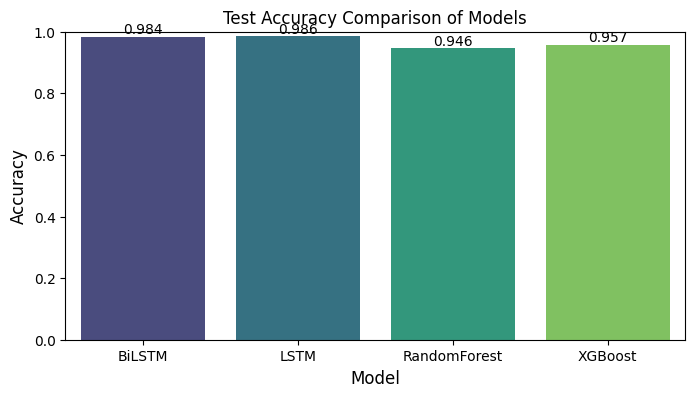

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ===========================
# Accuracy Comparison Plot
# ===========================
plt.figure(figsize=(8,4))
sns.barplot(x="Model", y="Test Accuracy", data=comp_df, palette="viridis")
plt.ylim(0,1)  # since accuracy ranges from 0 to 1
plt.title("Test Accuracy Comparison of Models", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xlabel("Model", fontsize=12)

# Annotate bars with values
for i, acc in enumerate(comp_df["Test Accuracy"]):
    plt.text(i, acc + 0.01, f"{acc:.3f}", ha='center', fontsize=10)

plt.show()


In [ ]:
# --------------------------
# 1️⃣ Deep models (BiLSTM & LSTM)
# --------------------------
deep_train_acc = {}
for name, model in [("BiLSTM", global_bilstm), ("LSTM", global_lstm)]:
    train_acc = float(model.evaluate(X_train_seq, y_train_arr, verbose=0)[1])
    deep_train_acc[name] = train_acc
    print(f"{name} train accuracy: {train_acc:.4f}")

# --------------------------
# 2️⃣ ML models (RandomForest & XGBoost)
# --------------------------
# Use the final trained models
ml_train_acc = {}
final_rf_acc = final_rf.score(X_train_tfidf, y_train)
final_xgb_acc = final_xgb.score(X_train_tfidf, y_train)
ml_train_acc["RandomForest"] = final_rf_acc
ml_train_acc["XGBoost"] = final_xgb_acc

print(f"RandomForest train accuracy: {final_rf_acc:.4f}")
print(f"XGBoost train accuracy: {final_xgb_acc:.4f}")

# --------------------------
# Combine all for easy view
# --------------------------
all_train_acc = {**deep_train_acc, **ml_train_acc}
train_acc_df = pd.DataFrame(list(all_train_acc.items()), columns=["Model", "Train Accuracy"])
print("\n=== All Models Train Accuracy ===")
print(train_acc_df)


BiLSTM train accuracy: 0.9821
LSTM train accuracy: 0.9840
RandomForest train accuracy: 0.9453
XGBoost train accuracy: 0.9583

=== All Models Train Accuracy ===
          Model  Train Accuracy
0        BiLSTM        0.982066
1          LSTM        0.984005
2  RandomForest        0.945311
3       XGBoost        0.958317


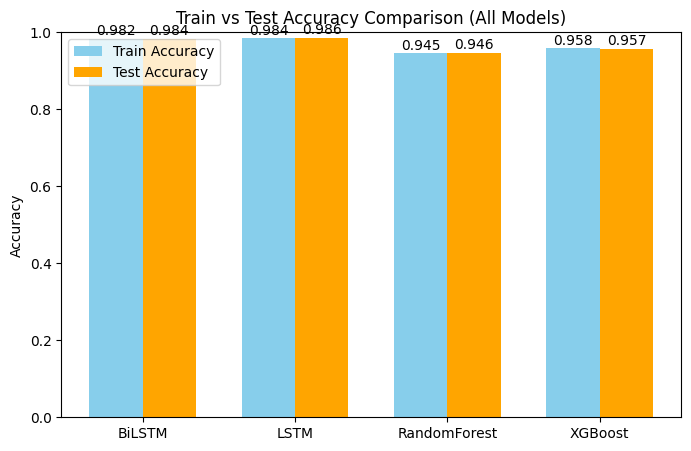

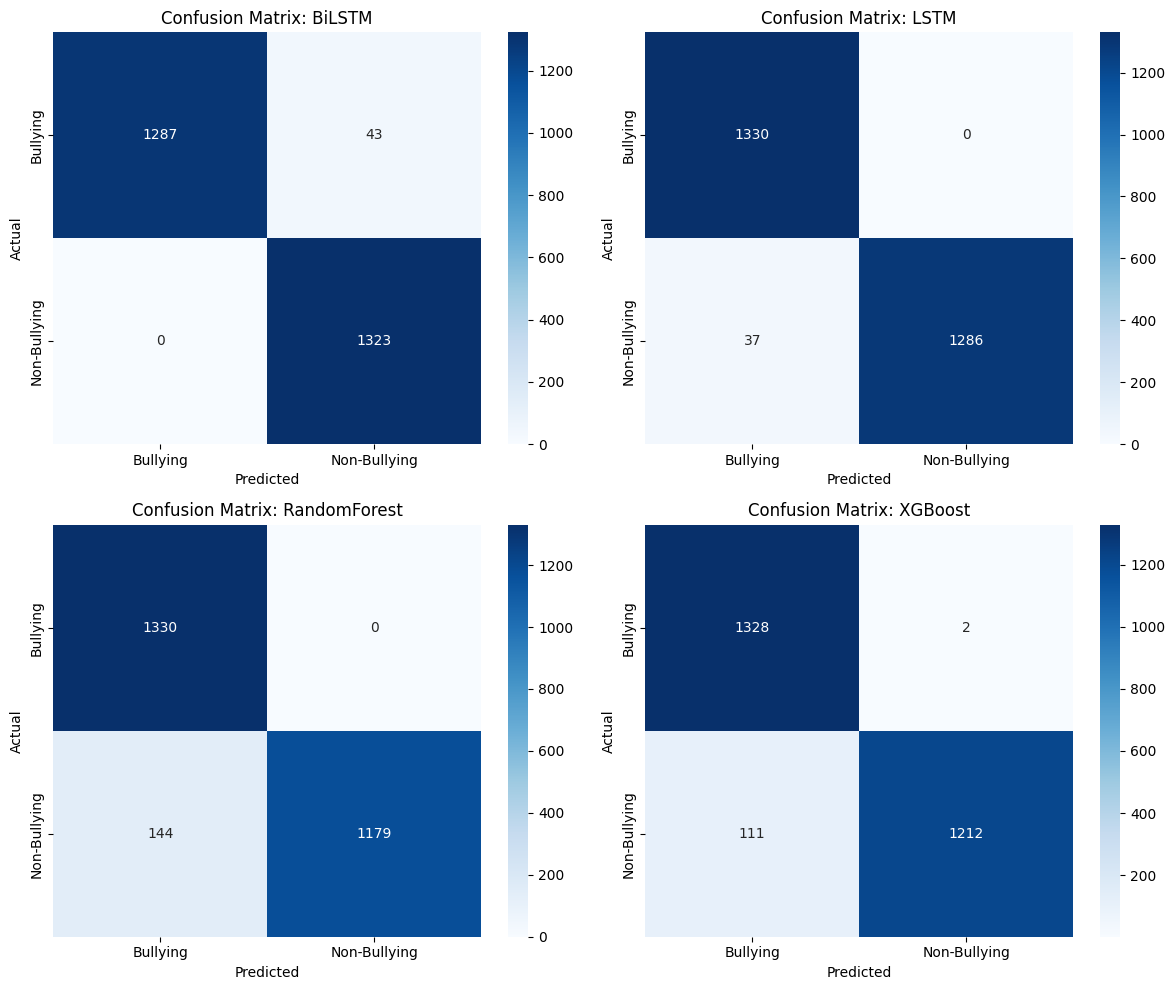

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# ===========================
# Train vs Test Accuracy Plot
# ===========================
models_list = list(all_train_acc.keys())
train_acc_list = [all_train_acc[m] for m in models_list]
test_acc_list = [all_test_acc[m] for m in models_list]

x = np.arange(len(models_list))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, train_acc_list, width, label='Train Accuracy', color='skyblue')
plt.bar(x + width/2, test_acc_list, width, label='Test Accuracy', color='orange')
plt.xticks(x, models_list)
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy Comparison (All Models)")
plt.legend()

# Annotate bars
for i in range(len(models_list)):
    plt.text(i - width/2, train_acc_list[i]+0.01, f"{train_acc_list[i]:.3f}", ha='center')
    plt.text(i + width/2, test_acc_list[i]+0.01, f"{test_acc_list[i]:.3f}", ha='center')

plt.show()

# ===========================
# Confusion Matrix Subplots
# ===========================
y_pred_bilstm = np.argmax(global_bilstm.predict(X_test_seq, verbose=0), axis=1)
y_pred_lstm   = np.argmax(global_lstm.predict(X_test_seq, verbose=0), axis=1)
y_pred_rf     = final_rf.predict(X_test_tfidf)
y_pred_xgb    = final_xgb.predict(X_test_tfidf)

preds = [y_pred_bilstm, y_pred_lstm, y_pred_rf, y_pred_xgb]
titles = ["BiLSTM", "LSTM", "RandomForest", "XGBoost"]

# For readable axes
inv_label_map = {v:k for k,v in label_map.items()}
target_names = [inv_label_map[i] for i in range(len(inv_label_map))]

fig, axes = plt.subplots(2,2, figsize=(12,10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    cm = confusion_matrix(y_test_arr, preds[i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=target_names, yticklabels=target_names)
    ax.set_title(f"Confusion Matrix: {titles[i]}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()
